In [1]:
import sys
sys.path.insert(0, "..")

import sudspy

# Block level

In [2]:
from sudspy.utils import print_suds_block_structure
from sudspy.utils import test_collect_comments


print_suds_block_structure(
    "../data/multi_stations/2_stations.sud",
    max_blocks=4
)


SUDS structure walk for: ../data/multi_stations/2_stations.sud

  STATIONCOMP  @ offset 0
  INSTRUMENT   @ offset 120

------------------------------------------------------------------------
DESCRIPTRACE @ offset 246
  waveform: VW.TRPU..CHE
------------------------------------------------------------------------
  COMMENT      @ offset 60354   [context=CHE]
    length=459

[truncated]


## Parser level

## Collection level

In [3]:
from sudspy.collections import collect_stations, collect_instruments, collect_comments

In [4]:
stats = collect_stations("../data/multi_stations/2_stations.sud")
stats.keys()

dict_keys(['VW.TRPU.CHE', 'VW.LOCU.CHE', 'VW.LOCU.CHN', 'VW.TRPU.CHZ', 'VW.LOCU.CHZ', 'VW.TRPU.CHN'])

In [7]:
instruments = collect_instruments("../data/multi_stations/2_stations.sud")
instruments.keys()

dict_keys(['VW.TRPU.CHE', 'VW.LOCU.CHE', 'VW.LOCU.CHN', 'VW.TRPU.CHZ', 'VW.LOCU.CHZ', 'VW.TRPU.CHN'])

In [12]:
comments = collect_comments("../data/multi_stations/2_stations.sud")
comments.keys()

dict_keys(['VW.TRPU.CHE', 'VW.LOCU.CHE', 'VW.LOCU.CHN', 'VW.TRPU.CHZ', 'VW.LOCU.CHZ', 'VW.TRPU.CHN'])

# Obspy  level

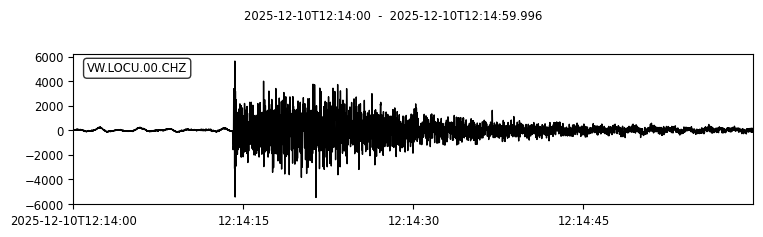

In [9]:
st = sudspy.read_suds_stream("../data/single_chan/locu_seismosphere.sud", default_location="00")
st[0].plot();

In [10]:
inv = sudspy.read_suds_inv("../data/single_chan/locu_seismosphere.sud", default_location="00")

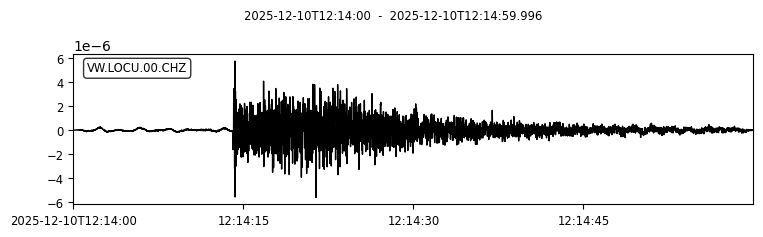

In [12]:
st[0].plot();

In [11]:
st.remove_response(
    inventory=inv)

1 Trace(s) in Stream:
VW.LOCU.00.CHZ | 2025-12-10T12:14:00.000000Z - 2025-12-10T12:14:59.996000Z | 250.0 Hz, 15000 samples

In [16]:
picks = sudspy.read_suds_picks(
    "../data/multi_chan_picks/locu.dmx",
    location_code=""
)

for p in picks:
    print(p)

Pick
	 resource_id: ResourceIdentifier(id="smi:local/8071feed-4d2f-4d51-905b-c9c0135a5d84")
	        time: UTCDateTime(2025, 12, 10, 12, 14, 19, 885000)
	 waveform_id: WaveformStreamID(network_code='VW', station_code='LOCU', channel_code='CHN', location_code='')
	  phase_hint: 'S'
Pick
	 resource_id: ResourceIdentifier(id="smi:local/29a5a4ef-504a-44ff-af16-7a2f0535fb12")
	        time: UTCDateTime(2025, 12, 10, 12, 14, 14, 130000)
	 waveform_id: WaveformStreamID(network_code='VW', station_code='LOCU', channel_code='CHZ', location_code='')
	  phase_hint: 'P'


## Utils

In [17]:
%%time
# --- build merged 3C stream ---
# discover channels present in the stream
chans = sorted({tr.stats.channel.strip() for tr in st})

merged = Stream()

for ch in chans:
    traces = [tr for tr in st if tr.stats.channel.strip() == ch]
    if not traces:
        continue
    merged += fast_merge_safe(
                traces,
                gap_fill="nan",
                overlap="trim",
            )

merged.write("fast_merge_safe.mseed", format="MSEED")

NameError: name 'Stream' is not defined